# Diabetes Prediction - Full Pipeline + Deployment
This notebook does everything in one clean, correctly-ordered run:
1. Load data
2. Fix fake zeros
3. Fix skew
4. Cap outliers
5. Check correlation (VIF)
6. Train/test split (stratified)
7. Scale features (fit on train only)
8. Train Logistic Regression
9. Evaluate
10. Save every artifact needed for deployment
11. Define and test a `predict_diabetes()` function using the saved artifacts

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix, roc_auc_score)


## 1. Load the data

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, names=columns)

print("Shape:", df.shape)
df.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Fix fake zeros (0 doesn't make sense for these columns)
We save the medians now — deployment will reuse these exact numbers, since a single new patient row has no distribution of its own to compute a median from.

In [3]:
cols_with_fake_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_with_fake_zero] = df[cols_with_fake_zero].replace(0, np.nan)
fake_zero_medians = df[cols_with_fake_zero].median().to_dict()   # save BEFORE filling
df[cols_with_fake_zero] = df[cols_with_fake_zero].fillna(fake_zero_medians)

print("Medians used to fill fake zeros:")
print(fake_zero_medians)
print("\nDuplicate rows:", df.duplicated().sum())


Medians used to fill fake zeros:
{'Glucose': 117.0, 'BloodPressure': 72.0, 'SkinThickness': 29.0, 'Insulin': 125.0, 'BMI': 32.3}

Duplicate rows: 0


## 3. Separate target, drop it from the feature set

In [4]:
df1 = df.copy()                  # keeps Outcome, used later for y
df = df.drop(columns='Outcome')  # df now holds only features


## 4. Fix skew
Columns with skew > 1 get `log1p` (strong fix). Columns with skew between 0.5 and 1 get `sqrt` (gentler fix). We save exactly which columns went into which group, since the same split must be re-applied at deployment.

In [5]:
df_skew1 = df.skew()[df.skew() >= 0.5]
strong_skew_cols = df_skew1[df_skew1 > 1].index.tolist()
mild_skew_cols = df_skew1[df_skew1 <= 1].index.tolist()

print("Strong skew (log1p):", strong_skew_cols)
print("Mild skew (sqrt):", mild_skew_cols)

for col in strong_skew_cols:
    df[col] = np.sign(df[col]) * np.log1p(abs(df[col]))
for col in mild_skew_cols:
    df[col] = np.sign(df[col]) * np.sqrt(abs(df[col]))

print("\nSkew after fix:")
print(df.skew())


Strong skew (log1p): ['Insulin', 'DiabetesPedigreeFunction', 'Age']
Mild skew (sqrt): ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI']

Skew after fix:
Pregnancies                -0.158938
Glucose                     0.253892
BloodPressure               0.141885
SkinThickness              -0.138269
Insulin                    -0.175078
BMI                         0.255761
DiabetesPedigreeFunction    1.117942
Age                         0.614664
dtype: float64


## 5. Cap remaining outliers
This is measured on the already skew-fixed data (matching the order used in the original notebook). Unlike before, we now actually **cap** the values with `.clip()`, not just print the counts — and we save the lower/upper bounds so deployment can apply the exact same caps to new data.

In [6]:
cols_to_check = df.skew()[df.skew() > 0.5].index.tolist()

outlier_bounds = {}
for col in cols_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_bounds[col] = {'lower': lower, 'upper': upper}
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier bounds saved for these columns:")
print(outlier_bounds)

# confirm no outliers remain in these columns
remaining = {}
for col, b in outlier_bounds.items():
    remaining[col] = ((df[col] < b['lower']) | (df[col] > b['upper'])).sum()
print("\nRemaining outliers after capping (should all be 0):")
print(remaining)


Outlier bounds saved for these columns:
{'DiabetesPedigreeFunction': {'lower': np.float64(-0.1840877009304483), 'upper': np.float64(0.8884953652037719)}, 'Age': {'lower': np.float64(2.440685134745449), 'upper': np.float64(4.51586030840612)}}

Remaining outliers after capping (should all be 0):
{'DiabetesPedigreeFunction': np.int64(0), 'Age': np.int64(0)}


## 6. Check correlation / multicollinearity (VIF)
VIF < 5 for a feature means it's fine to keep. This step doesn't change the data — it only helps decide which columns belong in `final_features`.

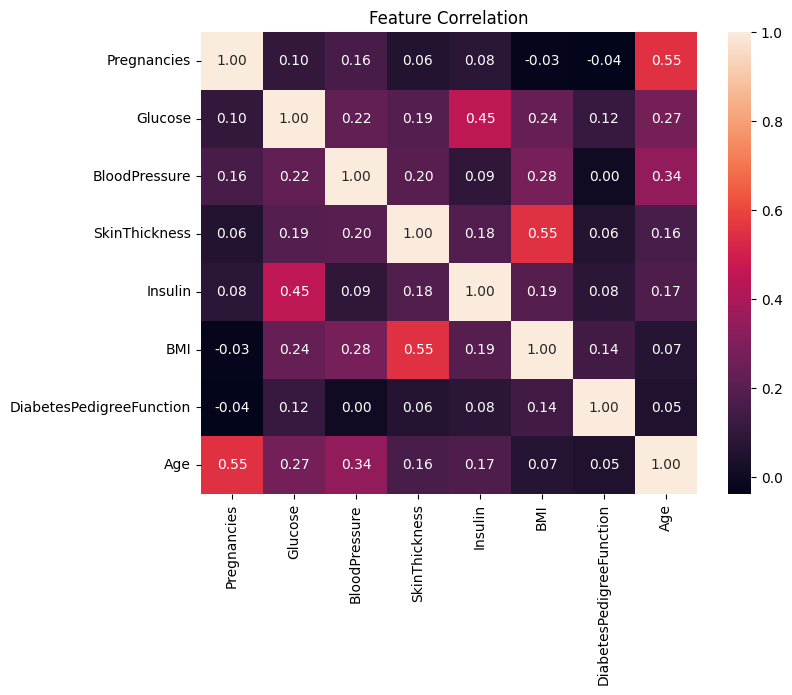

                    feature       VIF
6  DiabetesPedigreeFunction  1.037867
2             BloodPressure  1.239245
4                   Insulin  1.278256
1                   Glucose  1.375506
0               Pregnancies  1.452655
3             SkinThickness  1.475943
5                       BMI  1.579278
7                       Age  1.689782

No multicollinearity issues — keeping all features.


In [7]:
corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Feature Correlation")
plt.show()

x_with_const = sm.add_constant(df)
vif_data = pd.DataFrame()
vif_data['feature'] = x_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(x_with_const.values, i)
                    for i in range(x_with_const.shape[1])]
vif_data = vif_data[vif_data['feature'] != 'const'].reset_index(drop=True)

print(vif_data.sort_values(by="VIF"))

if (vif_data['VIF'] < 5).all():
    print("\nNo multicollinearity issues — keeping all features.")
else:
    print("\nHigh VIF features (consider dropping):")
    print(vif_data[vif_data['VIF'] >= 5])


## 7. Class balance check

In [8]:
print(df1['Outcome'].value_counts())
print(df1['Outcome'].value_counts(normalize=True))


Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


## 8. Define features/target, save final feature order

In [9]:
x = df
y = df1['Outcome']

final_features = list(x.columns)
print("Final features saved:", final_features)


Final features saved: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


## 9. Train/test split (stratified, so both sets keep the ~65/35 class ratio)

In [10]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", xtrain.shape, "Test shape:", xtest.shape)


Train shape: (614, 8) Test shape: (154, 8)


## 10. Scale features
**Important fix**: fit the scaler on `xtrain` only, then just `transform` (not `fit_transform`) on `xtest`. This avoids data leakage and matches how a real deployed scaler behaves — it never re-learns from new data.

In [11]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(xtrain)
x_test_scaled = sc.transform(xtest)   # transform only, not fit_transform


## 11. Train the model

In [12]:
model = LogisticRegression(class_weight='balanced')
model.fit(x_train_scaled, ytrain)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## 12. Evaluate

In [13]:
ypred = model.predict(x_test_scaled)
ypredproba = model.predict_proba(x_test_scaled)

print("Accuracy:", accuracy_score(ytest, ypred))
print("Precision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))
print("F1 Score:", f1_score(ytest, ypred))
print("Confusion Matrix:\n", confusion_matrix(ytest, ypred))
print("AUC:", roc_auc_score(ytest, ypredproba[:, 1]))


Accuracy: 0.7207792207792207
Precision: 0.582089552238806
Recall: 0.7222222222222222
F1 Score: 0.6446280991735537
Confusion Matrix:
 [[72 28]
 [15 39]]
AUC: 0.8185185185185185


## 13. Save every artifact needed for deployment
6 files: the model, the scaler, the fake-zero medians, the outlier bounds, the skew column groups, and the final feature order.

In [14]:
joblib.dump(model, 'model.pkl')
joblib.dump(sc, 'scaler.pkl')
joblib.dump(fake_zero_medians, 'fake_zero_medians.pkl')
joblib.dump(outlier_bounds, 'outlier_bounds.pkl')
joblib.dump({'strong': strong_skew_cols, 'mild': mild_skew_cols}, 'skew_cols.pkl')
joblib.dump(final_features, 'final_features.pkl')

print("All files saved!")

for f in ['model.pkl', 'scaler.pkl', 'fake_zero_medians.pkl',
          'outlier_bounds.pkl', 'skew_cols.pkl', 'final_features.pkl']:
    print(f, "->", "Found" if os.path.exists(f) else "MISSING")


All files saved!
model.pkl -> Found
scaler.pkl -> Found
fake_zero_medians.pkl -> Found
outlier_bounds.pkl -> Found
skew_cols.pkl -> Found
final_features.pkl -> Found


## 14. The deployment function
This repeats the *exact* pipeline above, in the *same order*, on ONE new row of raw patient data, using only the saved artifacts (never recalculating anything from the new data itself).

**Correct order** (matches this notebook): fake-zero fix -> skew fix -> outlier capping -> select final features -> scale -> predict.

In [15]:
def predict_diabetes(raw_input: dict):
    """
    raw_input: a dict with keys matching the original column names, e.g.
    {'Pregnancies': 2, 'Glucose': 120, 'BloodPressure': 70, 'SkinThickness': 20,
     'Insulin': 85, 'BMI': 28.5, 'DiabetesPedigreeFunction': 0.5, 'Age': 33}
    """
    model = joblib.load('model.pkl')
    sc = joblib.load('scaler.pkl')
    fake_zero_medians = joblib.load('fake_zero_medians.pkl')
    outlier_bounds = joblib.load('outlier_bounds.pkl')
    skew_cols = joblib.load('skew_cols.pkl')
    final_features = joblib.load('final_features.pkl')

    row = pd.DataFrame([raw_input])

    # 1. fake-zero fix
    for col, med in fake_zero_medians.items():
        if row.loc[0, col] == 0:
            row.loc[0, col] = med

    # 2. skew fix
    for col in skew_cols['strong']:
        row[col] = np.sign(row[col]) * np.log1p(abs(row[col]))
    for col in skew_cols['mild']:
        row[col] = np.sign(row[col]) * np.sqrt(abs(row[col]))

    # 3. outlier capping
    for col, b in outlier_bounds.items():
        row[col] = row[col].clip(lower=b['lower'], upper=b['upper'])

    # 4. select final features, in the right order
    row = row[final_features]

    # 5. scale
    row_scaled = sc.transform(row)

    # 6. predict
    prediction = model.predict(row_scaled)[0]
    probability = model.predict_proba(row_scaled)[0][1]

    return {'prediction': int(prediction), 'probability': round(float(probability), 4)}


## 15. Test it with one manual example
Try a few different made-up patients and see if the predictions look sensible.

In [16]:
example_patient = {
    'Pregnancies': 2, 'Glucose': 120, 'BloodPressure': 70, 'SkinThickness': 20,
    'Insulin': 85, 'BMI': 28.5, 'DiabetesPedigreeFunction': 0.5, 'Age': 33
}

result = predict_diabetes(example_patient)
print(result)


{'prediction': 0, 'probability': 0.3266}


### Next step
Once this all runs cleanly, copy the imports + `predict_diabetes()` function into a separate `app.py` file, load the 6 `.pkl` files, and wrap it in a Streamlit form so you can enter patient values and get predictions from a browser.